# 🐝 Honeybee vs Bumblebee Classification — Deep Learning
### Transfer Learning + Fine-Tuning with MobileNetV2

## 1. Imports & Configuration

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)
import pandas as pd

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


In [5]:
# ── Paths & Hyperparameters ──────────────────────────────────────
TRAIN_DIR   = '../data/processed/train'
TEST_DIR    = '../data/processed/test'
IMAGE_SIZE  = (224, 224)
BATCH_SIZE  = 32
SEED        = 42
AUTOTUNE    = tf.data.AUTOTUNE

## 2. Load Datasets

In [6]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset='training',
    seed=SEED
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset='validation',
    seed=SEED
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds_raw.class_names
print('Classes:', class_names)

Found 1323 files belonging to 2 classes.
Using 1059 files for training.
Found 1323 files belonging to 2 classes.
Using 264 files for validation.
Found 331 files belonging to 2 classes.
Classes: ['bumblebee', 'honeybee']


## 3. Data Augmentation & Preprocessing

> **Why augmentation?** With only ~1300 images, augmentation artificially expands the dataset and helps prevent overfitting by showing the model different variations of the same image.

In [7]:
# Augmentation layers (applied only during training)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name='data_augmentation')

# MobileNetV2 expects inputs scaled to [-1, 1]
def preprocess(image, label):
    return preprocess_input(image), label

def augment_and_preprocess(image, label):
    image = data_augmentation(image, training=True)
    return preprocess_input(image), label

train_ds = train_ds_raw.map(augment_and_preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds_raw.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds_raw.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print('Datasets ready.')

Datasets ready.


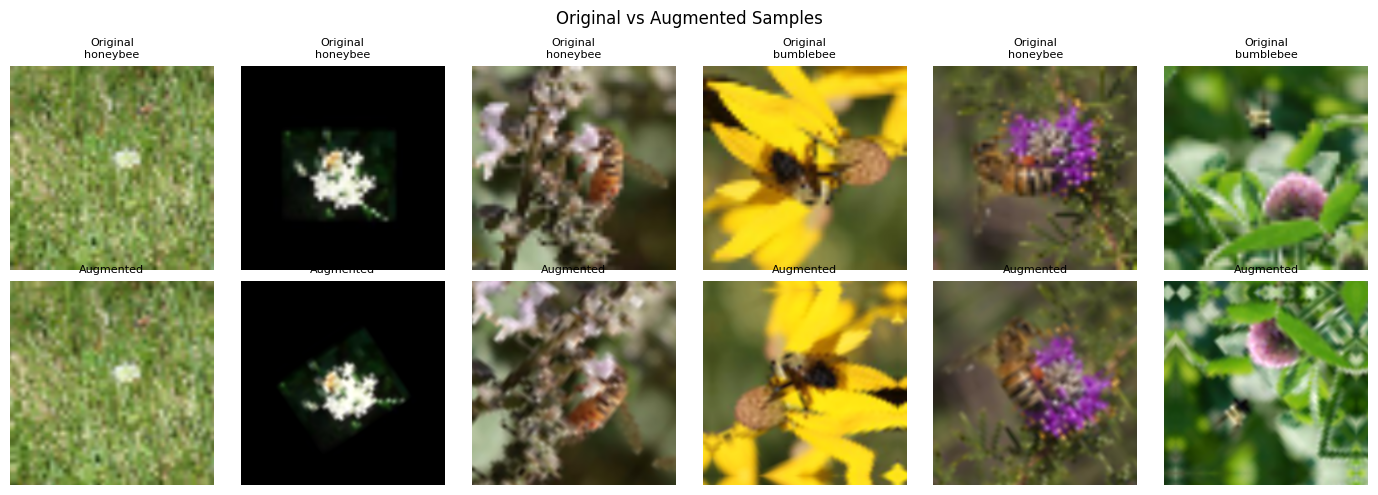

In [8]:
# Visualize original vs augmented samples
plt.figure(figsize=(14, 5))
for images, labels in train_ds_raw.take(1):
    for i in range(6):
        ax = plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(f'Original\n{class_names[labels[i]]}', fontsize=8)
        plt.axis('off')

        ax = plt.subplot(2, 6, i + 7)
        aug = data_augmentation(tf.expand_dims(images[i], 0), training=True)
        plt.imshow(aug[0].numpy().astype('uint8'))
        plt.title('Augmented', fontsize=8)
        plt.axis('off')

plt.suptitle('Original vs Augmented Samples', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Build the Model

**Architecture:**
```
Input (224×224×3)
  → MobileNetV2 backbone  ← pre-trained on ImageNet
  → GlobalAveragePooling2D
  → BatchNormalization
  → Dense(256, relu) → Dropout(0.4)
  → Dense(128, relu) → Dropout(0.3)
  → Dense(1, sigmoid)   ← binary output
```

> **Why sigmoid + 1 unit?** Binary classification. Outputs probability of class 1 (bumblebee). Threshold 0.5 → prediction.

In [9]:
def build_model(trainable_backbone=False, unfreeze_from_layer=None):
    """
    Build MobileNetV2-based transfer learning model.

    Args:
        trainable_backbone  : if True, backbone layers can be trained
        unfreeze_from_layer : layer name to start unfreezing from (fine-tuning)
    """
    backbone = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    backbone.trainable = trainable_backbone

    # Phase 2: selectively unfreeze top layers
    if trainable_backbone and unfreeze_from_layer:
        set_trainable = False
        for layer in backbone.layers:
            if layer.name == unfreeze_from_layer:
                set_trainable = True
            layer.trainable = set_trainable
        trainable_count = sum(1 for l in backbone.layers if l.trainable)
        print(f'Trainable backbone layers: {trainable_count}')

    inputs  = tf.keras.Input(shape=(224, 224, 3))
    x       = backbone(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(128, activation='relu')(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return Model(inputs, outputs)

## 5. Phase 1 — Train Head Only (Backbone Frozen)

> The backbone weights are frozen. Only the Dense layers on top are trained. This prevents the randomly-initialized head from destroying ImageNet weights.

In [10]:
model = build_model(trainable_backbone=False)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,065 (10.01 MB)

 Trainable params: 363,521 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [11]:
callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_phase1.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1)
]

history1 = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=callbacks_phase1
)

Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.6291 - auc: 0.6850 - loss: 0.6999
Epoch 1: val_accuracy improved from None to 0.78030, saving model to best_model_phase1.keras

Epoch 1: finished saving model to best_model_phase1.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 37s 839ms/step - accuracy: 0.6808 - auc: 0.7536 - loss: 0.6351 - val_accuracy: 0.7803 - val_auc: 0.8852 - val_loss: 0.4537 - learning_rate: 0.0010
Epoch 2/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.7462 - auc: 0.8374 - loss: 0.5340
Epoch 2: val_accuracy improved from 0.78030 to 0.78409, saving model to best_model_phase1.keras

Epoch 2: finished saving model to best_model_phase1.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 39s 763ms/step - accuracy: 0.7639 - auc: 0.8535 - loss: 0.5049 - val_accuracy: 0.7841 - val_auc: 0.8828 - val_loss: 0.4913 - learning_rate: 0.0010
Epoch 3/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.8055 - auc: 0.8886 - loss: 0.4514
Epoch 3: val_accuracy did not improve from 0.

## 6. Phase 2 — Fine-Tune Top Backbone Layers

> We unfreeze MobileNetV2 layers from `block_14_expand` onward (~30 layers). Using a very small learning rate (1e-5) to gently adapt these layers to bee-specific features without destroying ImageNet knowledge.

**Why fine-tune?** Frozen ImageNet features are generic (edges, textures). Fine-tuning adapts the top layers to learn bee-specific patterns like fuzz, stripes, and wing shapes.

In [12]:
FINE_TUNE_FROM = 'block_14_expand'

model_ft = build_model(
    trainable_backbone=True,
    unfreeze_from_layer=FINE_TUNE_FROM
)

# Load best weights from Phase 1
model_ft.load_weights('best_model_phase1.keras')

model_ft.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # very small LR
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

Trainable backbone layers: 29


In [13]:
callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_phase2.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=5, min_lr=1e-8, verbose=1)
]

history2 = model_ft.fit(
    train_ds,
    epochs=40,
    validation_data=val_ds,
    callbacks=callbacks_phase2
)

Epoch 1/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.8225 - auc: 0.8950 - loss: 0.4578
Epoch 1: val_accuracy improved from None to 0.85227, saving model to best_model_phase2.keras

Epoch 1: finished saving model to best_model_phase2.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 43s 945ms/step - accuracy: 0.8130 - auc: 0.8908 - loss: 0.4500 - val_accuracy: 0.8523 - val_auc: 0.9271 - val_loss: 0.3482 - learning_rate: 1.0000e-05
Epoch 2/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 694ms/step - accuracy: 0.8263 - auc: 0.9006 - loss: 0.4272
Epoch 2: val_accuracy improved from 0.85227 to 0.86742, saving model to best_model_phase2.keras

Epoch 2: finished saving model to best_model_phase2.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 30s 866ms/step - accuracy: 0.8329 - auc: 0.9080 - loss: 0.3985 - val_accuracy: 0.8674 - val_auc: 0.9287 - val_loss: 0.3482 - learning_rate: 1.0000e-05
Epoch 3/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.8187 - auc: 0.9137 - loss: 0.3877
Epoch 3: val_accuracy did not improve

## 7. Training Curves

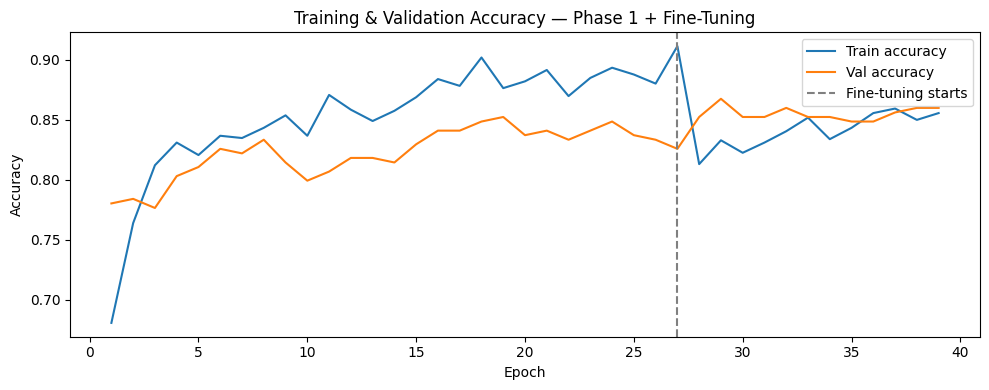

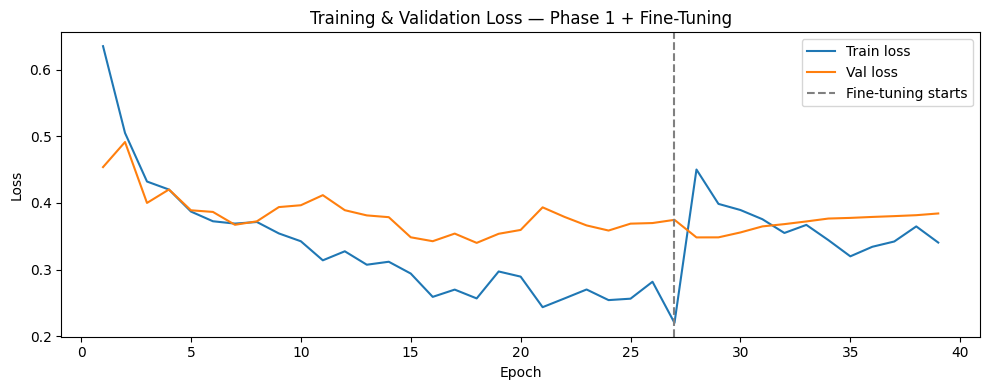

In [14]:
def plot_history(h1, h2, metric='accuracy'):
    """Plot combined Phase 1 + Phase 2 training curves."""
    combined     = h1.history[metric]     + h2.history[metric]
    combined_val = h1.history[f'val_{metric}'] + h2.history[f'val_{metric}']
    epochs_total = range(1, len(combined) + 1)
    phase2_start = len(h1.history[metric])

    plt.figure(figsize=(10, 4))
    plt.plot(epochs_total, combined,     label=f'Train {metric}')
    plt.plot(epochs_total, combined_val, label=f'Val {metric}')
    plt.axvline(phase2_start, color='gray', linestyle='--', label='Fine-tuning starts')
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.title(f'Training & Validation {metric.capitalize()} — Phase 1 + Fine-Tuning')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history1, history2, 'accuracy')
plot_history(history1, history2, 'loss')

## 8. Evaluate on Test Set

In [15]:
# Load best fine-tuned weights
model_ft.load_weights('best_model_phase2.keras')

y_true, y_prob = [], []

for images, labels in test_ds:
    probs = model_ft.predict(images, verbose=0)
    y_prob.extend(probs.flatten())
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

test_acc = np.mean(y_pred == y_true)
print(f'Test Accuracy: {test_acc:.4f}\n')
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

Test Accuracy: 0.8731

Classification Report:
              precision    recall  f1-score   support

   bumblebee       0.91      0.83      0.87       166
    honeybee       0.84      0.92      0.88       165

    accuracy                           0.87       331
   macro avg       0.88      0.87      0.87       331
weighted avg       0.88      0.87      0.87       331



## 9. Confusion Matrix

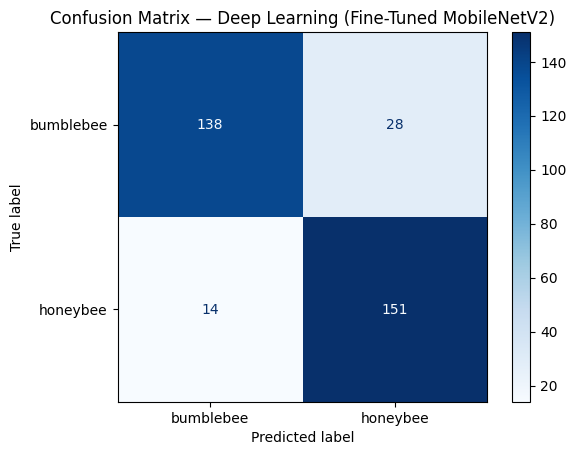

In [16]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Deep Learning (Fine-Tuned MobileNetV2)')
plt.show()

## 10. ROC Curve

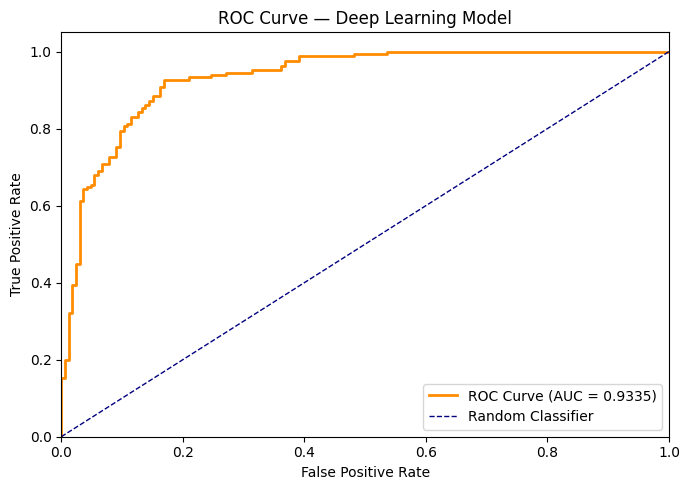

In [17]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Deep Learning Model')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 11. Visualize Predictions on Test Images

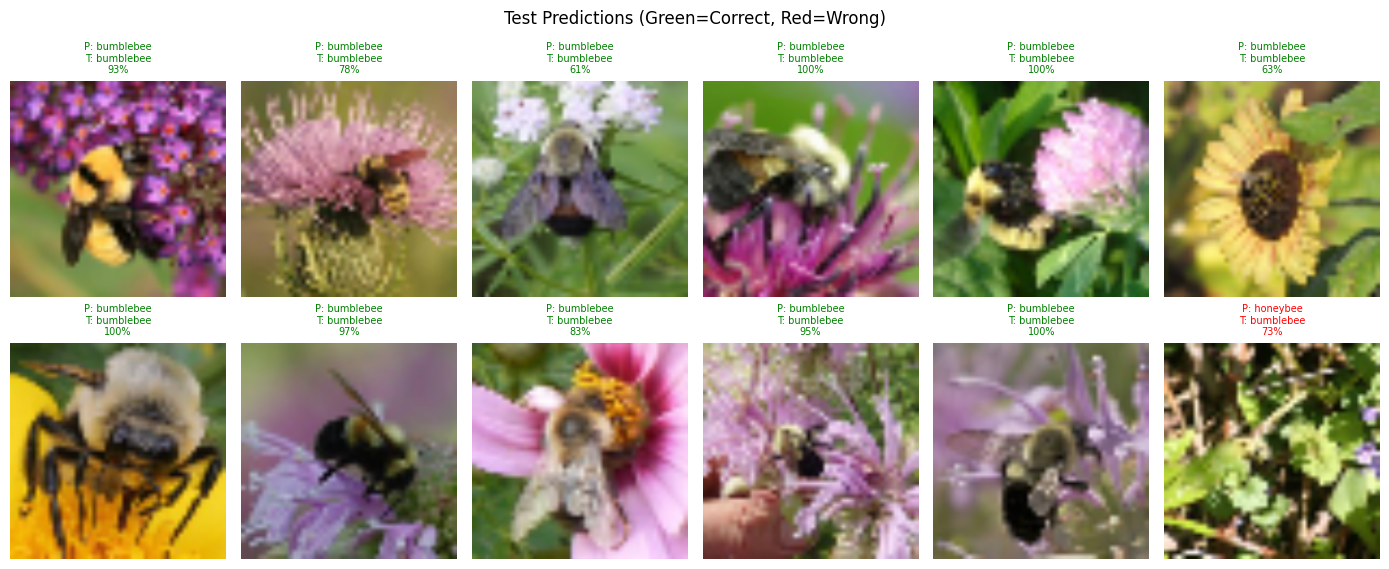

In [18]:
plt.figure(figsize=(14, 6))
for images, labels in test_ds_raw.take(1):
    preprocessed = preprocess_input(tf.cast(images, tf.float32))
    probs = model_ft.predict(preprocessed, verbose=0).flatten()

    for i in range(min(12, len(images))):
        plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        pred_label = class_names[int(probs[i] >= 0.5)]
        true_label = class_names[labels[i]]
        color = 'green' if pred_label == true_label else 'red'
        confidence = probs[i] if int(probs[i] >= 0.5) == 1 else 1 - probs[i]
        plt.title(f'P: {pred_label}\nT: {true_label}\n{confidence:.0%}',
                  fontsize=7, color=color)
        plt.axis('off')

plt.suptitle('Test Predictions (Green=Correct, Red=Wrong)', fontsize=12)
plt.tight_layout()
plt.show()